# Twin-2K-500 — Data Exploration

**Deliverable 1** for the Research Engineer take-home. This notebook:

1. Loads both Hugging Face subsets (`full_persona`, `wave_split`) plus the question catalog / response CSVs.
2. Profiles dataset structure, question types, and how each type would be scored.
3. Checks sample distributions against known US population benchmarks (representativeness).
4. **Computes the human test–retest reliability ceiling** (the most important number in this notebook —
   it is the bar any model has to clear, and an upper bound on what "good" even means for this task).
5. Surfaces the **wave 1–3 → wave 4 leakage trap**: several wave-4 columns are *literal repeats* of
   earlier questions, so naively including them in a "persona" feature set lets a model see the answer.
6. Documents the dataset's biases / limitations.
7. Exports the full, untruncated key tables to a multi-sheet `.xlsx` for easy viewing in Excel.

> **Note on reproducibility:** first run downloads the Hugging Face dataset (~700MB). After that,
> catalog/CSV cells reuse the cache. Use `wave_split`, not `full_persona`, as the model persona
> (see §6). Column types must be joined via `csv_columns`, never `startswith(QuestionID)`.


## 1. Setup

In [2]:
# !pip install datasets huggingface_hub pandas numpy scipy matplotlib seaborn statsmodels -q

import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download
from datasets import load_dataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)

REPO_ID = "LLM-Digital-Twin/Twin-2K-500"


## 2. Dataset structure — the two HF configs

The dataset card documents **5 logical folders** but exposes **2 loadable HF configs** (the other
3 — question catalog/CSV, LLM simulation results, raw Qualtrics exports — are plain files fetched
with `hf_hub_download`, not `load_dataset` configs):

| Config | Rows | Purpose |
|---|---|---|
| `full_persona` | 2,058 | One row per person: `persona_text`, `persona_summary`, `persona_json` — wave-4 answers already merged in for any question that repeats. **Not what we want for the prediction task** — it leaks wave 4 into the "persona". |
| `wave_split` | 2,058 | The actual train/eval split: `wave1_3_persona_text/json` (predictors), `wave4_Q_wave4_A` (ground truth), `wave4_Q_wave1_3_A` (the human's *own* earlier answer to the same wave-4 question — this is what lets us compute test–retest reliability). |

We load both, plus the standalone question catalog and response CSVs, which give us clean tabular
data instead of parsing free-text/JSON personas for the quantitative EDA below.


In [ ]:
full_persona = load_dataset(REPO_ID, "full_persona")["data"].to_pandas()
wave_split   = load_dataset(REPO_ID, "wave_split")["data"].to_pandas()

# HF schema mismatch: full_persona.pid is string ("574"), wave_split.pid is int64 (574).
# Normalize so later merges / set comparisons work.
full_persona["pid"] = pd.to_numeric(full_persona["pid"], errors="raise").astype("int64")
wave_split["pid"]   = pd.to_numeric(wave_split["pid"], errors="raise").astype("int64")

print("full_persona:", full_persona.shape, " pid dtype:", full_persona["pid"].dtype)
print("wave_split  :", wave_split.shape, " pid dtype:", wave_split["pid"].dtype)
full_persona.head(2)


In [ ]:
wave_split.columns.tolist()


In [ ]:
# Sanity check: same 2,058 participants in both configs?
assert set(full_persona["pid"]) == set(wave_split["pid"])
print(f"{full_persona['pid'].nunique()} unique participants, consistent across both configs.")


### 2.1 The clean tabular layer (question catalog + response CSVs)

For anything numeric (distributions, reliability stats) we use the standardized CSVs rather than
parsing `persona_json` — same underlying data, far less friction.


In [8]:
catalog_path = hf_hub_download(
    repo_id=REPO_ID, repo_type="dataset",
    filename="question_catalog_and_human_response_csv/question_catalog.json",
)
with open(catalog_path, encoding="utf-8") as f:
    question_catalog = json.load(f)

print(f"{len(question_catalog)} QuestionIDs in the catalog "
      f"(these expand into ~500 individual scored items, e.g. matrix rows / slider statements).")

w13_num = pd.read_csv(hf_hub_download(
    repo_id=REPO_ID, repo_type="dataset",
    filename="question_catalog_and_human_response_csv/wave1_3_response.csv"))
w4_num = pd.read_csv(hf_hub_download(
    repo_id=REPO_ID, repo_type="dataset",
    filename="question_catalog_and_human_response_csv/wave4_response.csv"))

print("wave1_3_response.csv:", w13_num.shape, " (2,058 people x 761 columns incl. pid)")
print("wave4_response.csv  :", w4_num.shape, " (2,058 people x 127 columns incl. pid)")

# Official catalog field is `csv_columns` (a list). Do NOT match with
# col.startswith(QuestionID): QID290_5 would hit QID2 / QID29 first and
# mislabel Slider 0-100 items as MC/Matrix.
COL_TO_QUESTION = {}
for _q in question_catalog:
    for _c in _q.get("csv_columns") or []:
        COL_TO_QUESTION[_c] = _q

def question_meta(col: str) -> dict:
    q = COL_TO_QUESTION.get(col)
    if q is None:
        return {"qid": None, "qtype": "Unknown", "selector": None, "block": None,
                "is_descriptive": False, "range": None, "text": None}
    settings = q.get("Settings") or {}
    return {
        "qid": q.get("QuestionID"),
        "qtype": q.get("QuestionType") or "Unknown",
        "selector": settings.get("Selector"),
        "block": (q.get("BlockName") or "").strip(),
        "is_descriptive": bool(q.get("is_descriptive")),
        "range": q.get("Range"),
        "text": q.get("QuestionText"),
    }

n_unmapped = sum(1 for c in w13_num.columns if c != "pid" and c not in COL_TO_QUESTION)
print(f"Catalog csv_columns index: {len(COL_TO_QUESTION)} columns; "
      f"wave1-3 columns not in catalog: {n_unmapped}")


256 QuestionIDs in the catalog (these expand into ~500 individual scored items, e.g. matrix rows / slider statements).
wave1_3_response.csv: (2058, 761)  (2,058 people x 761 columns incl. pid)
wave4_response.csv  : (2058, 127)  (2,058 people x 127 columns incl. pid)
Catalog csv_columns index: 760 columns; wave1-3 columns not in catalog: 0


## 3. Question types — and how each would be scored

`question_catalog.json` gives a Qualtrics `QuestionType` per QuestionID (`MC`, `Matrix`, `Slider`,
`TE`, `DB`) plus `csv_columns` — the actual CSV fields. One Matrix/Slider QuestionID expands to
many scored items. **MC is not always single-choice:** `Settings.Selector` is `SAVR`/`SAHR`
(single) or `MAVR`/`MAHR` (multi-select, e.g. BDI). **DB is instructional** (`is_descriptive: true`)
and produces zero CSV columns — exclude it from scoring, do not treat it as "case-by-case".


In [10]:
qtype_counts = Counter(q.get("QuestionType", "Unknown") for q in question_catalog)
qtype_df = (pd.Series(qtype_counts, name="n_QuestionIDs")
              .sort_values(ascending=False)
              .rename_axis("QuestionType")
              .reset_index())
qtype_df


Out[1]: 
  QuestionType  n_QuestionIDs
0           MC            175
1       Matrix             36
2           TE             28
3           DB             14
4       Slider              3


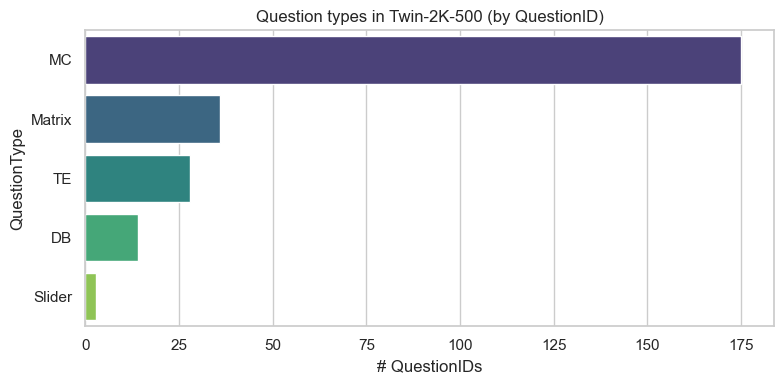

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=qtype_df, x="n_QuestionIDs", y="QuestionType", ax=ax, palette="viridis")
ax.set_title("Question types in Twin-2K-500 (by QuestionID)")
ax.set_xlabel("# QuestionIDs")
plt.tight_layout()
plt.show()


**Scoring mapping** (used later in `docs/03_eval_strategy.md`):

| QuestionType | In this catalog | Scoring metric |
|---|---|---|
| MC, selector SAVR/SAHR | 154 QuestionIDs (region, gender, pricing yes/no, …) | Accuracy / macro-F1 vs. a "predict the mode" baseline. Use MAE-on-code **only** if options are ordinal |
| MC, selector MAVR/MAHR | 21 QuestionIDs (BDI items, Wason) | **Not** single-label accuracy. Jaccard / per-option F1 on the binary `{QID}_{option}` columns |
| Matrix | 36 QuestionIDs (Big Five rows, bipolar economic items) | Per-item accuracy **and** ordinal MAE on the 1–k code ("off by 1" ≠ "off by 4") |
| Slider | 3 QuestionIDs → ~12 CSV columns, range 0–100 (`QID154`, `QID156`, `QID290_*`) | MAE / RMSE + Pearson r in native units. Exact-match is the wrong headline |
| TE | 28 QuestionIDs (`{QID}_TEXT` or form slots) | Numeric MAE if `ValidNumber` (e.g. anchoring); exclude free text from headline metrics |
| DB | 14 blocks | **Exclude** — no answer is collected |

There is no separate `MaxDiff` / `Multi-select` type in this catalog. Multi-select lives under MC.


In [13]:
MC_MULTI = {"MAVR", "MAHR"}

def scoring_metric(qtype: str, selector: str = None) -> str:
    if qtype == "MC" and selector in MC_MULTI:
        return "Jaccard / per-option F1 (multi-select; not single-label accuracy)"
    mapping = {
        "MC": "accuracy / macro-F1; MAE-on-code only if options are ordinal",
        "Matrix": "accuracy + mean absolute ordinal distance",
        "Slider": "MAE / RMSE + Pearson r (native 0-100 units)",
        "TE": "numeric MAE if ValidNumber; exclude free text from headline metrics",
        "DB": "exclude — instructional text, no answer collected",
    }
    return mapping.get(qtype, "case-by-case (inspect options/scale)")

qtype_df = qtype_df.copy()
qtype_df["suggested_metric"] = qtype_df["QuestionType"].map(scoring_metric)

mc_selector_counts = Counter(
    (q.get("Settings") or {}).get("Selector", "Unknown")
    for q in question_catalog if q.get("QuestionType") == "MC"
)
print("MC selectors (QuestionID level):", dict(mc_selector_counts))
print("DB with is_descriptive=True:",
      sum(1 for q in question_catalog if q.get("is_descriptive")))
qtype_df


MC selectors (QuestionID level): {'SAVR': 129, 'SAHR': 25, 'MAVR': 20, 'MAHR': 1}
DB with is_descriptive=True: 14
Out[1]: 
  QuestionType  n_QuestionIDs  \
0           MC            175   
1       Matrix             36   
2           TE             28   
3           DB             14   
4       Slider              3   

                                    suggested_metric  
0  accuracy / macro-F1; MAE-on-code only if optio...  
1          accuracy + mean absolute ordinal distance  
2  numeric MAE if ValidNumber; exclude free text ...  
3  exclude — instructional text, no answer collected  
4        MAE / RMSE + Pearson r (native 0-100 units)  


## 4. Distributions & representativeness

The dataset card claims a sample "representative of the US population." We check the core
demographic columns (age, gender, region, income, education) against known Census/ACS marginals.
Exact CSV column names come from `question_catalog.json` (`csv_columns` field) — the cell below
looks them up by keyword rather than hardcoding QIDs, since IDs can shift between dataset versions.
We then compare sample shares to U.S. Census Bureau ACS 2023 1-year estimates (bins recoded to the
survey's options). Deltas above 5 percentage points are treated as material representativeness gaps.


In [15]:
def find_columns(keyword: str):
    """Find catalog entries whose QuestionText mentions `keyword`, return their CSV columns."""
    hits = []
    for q in question_catalog:
        text = (q.get("QuestionText") or "").lower()
        if keyword.lower() in text:
            cols = q.get("csv_columns") or q.get("CSV_Column") or q.get("CSVColumn")
            hits.append((q.get("QuestionID"), q.get("QuestionText"), cols))
    return hits

for kw in ["how old", "assigned at birth", "currently live", "family income", "schooling"]:
    print(f"--- '{kw}' ---")
    for hit in find_columns(kw)[:3]:
        print(" ", hit)
    print()


--- 'how old' ---
  ('QID13', 'How old are you?', ['QID13'])

--- 'assigned at birth' ---
  ('QID12', 'What is the sex that you were assigned at birth?', ['QID12'])

--- 'currently live' ---
  ('QID11', 'Which part of the United States do you currently live in?', ['QID11'])
  ('QID23', 'Including yourself, how many people currently live in your household?', ['QID23'])

--- 'family income' ---
  ('QID21', 'Last year, what was your total family income from all sources, before taxes?', ['QID21'])

--- 'schooling' ---
  ('QID14', 'What is the highest level of schooling or degree that you have completed?', ['QID14'])



In [16]:
# Catalog field is `csv_columns` (not CSV_Column). These QIDs are MC brackets, not raw age/income.
DEMO_COLS = {
    "age": "QID13",        # How old are you?  18-29 / 30-49 / 50-64 / 65+
    "gender": "QID12",     # Sex assigned at birth
    "region": "QID11",     # US region
    "income": "QID21",     # Family income before taxes
    "education": "QID14",  # Highest schooling / degree
}

missing = [c for c in DEMO_COLS.values() if c not in w13_num.columns]
if missing:
    raise KeyError(f"Demographic columns not in wave1_3_response.csv: {missing}")

demo_df = w13_num[["pid"] + list(DEMO_COLS.values())].copy()
print(demo_df[list(DEMO_COLS.values())].nunique())
demo_df.describe(include="all")


QID13    4
QID12    2
QID11    5
QID21    5
QID14    6
dtype: int64
Out[1]: 
               pid        QID13        QID12        QID11        QID21  \
count  2058.000000  2058.000000  2058.000000  2058.000000  2058.000000   
mean   1029.500000     2.400389     1.507289     2.742468     3.133139   
std     594.237747     0.941683     0.500068     1.025088     1.457137   
min       1.000000     1.000000     1.000000     1.000000     1.000000   
25%     515.250000     2.000000     1.000000     2.000000     2.000000   
50%    1029.500000     2.000000     2.000000     3.000000     3.000000   
75%    1543.750000     3.000000     2.000000     3.000000     5.000000   
max    2058.000000     4.000000     2.000000     5.000000     5.000000   

             QID14  
count  2058.000000  
mean      4.144801  
std       1.332597  
min       1.000000  
25%       3.000000  
50%       5.000000  
75%       5.000000  
max       6.000000  


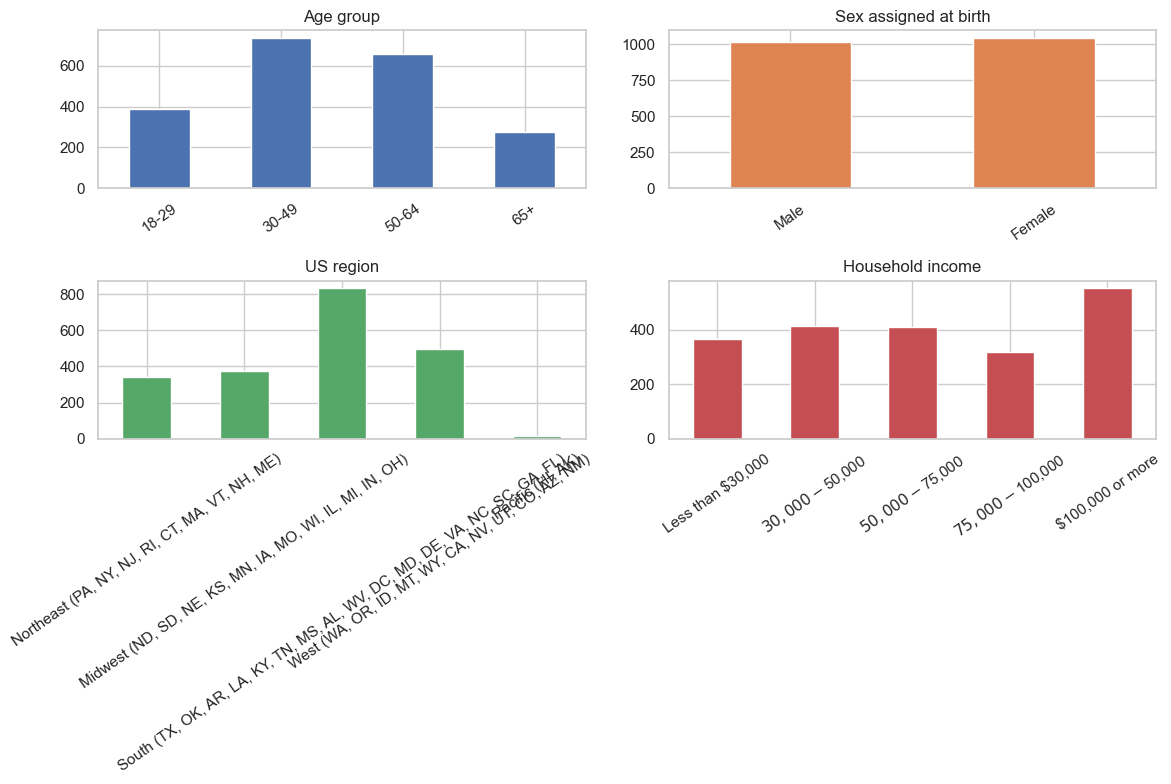

In [17]:
def option_labels(qid: str) -> dict:
    q = next(x for x in question_catalog if x.get("QuestionID") == qid)
    return {i + 1: lab for i, lab in enumerate(q.get("Options") or [])}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    ("age", "Age group", axes[0, 0], "#4C72B0"),
    ("gender", "Sex assigned at birth", axes[0, 1], "#DD8452"),
    ("region", "US region", axes[1, 0], "#55A868"),
    ("income", "Household income", axes[1, 1], "#C44E52"),
]

for key, title, ax, color in plot_specs:
    col = DEMO_COLS[key]
    labels = option_labels(col)
    series = demo_df[col].map(labels)
    order = list(labels.values())
    series.value_counts().reindex(order).plot.bar(ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=35)

plt.tight_layout()
plt.show()


**Representativeness check.** The dataset card *claims* a US-representative sample. The next cell
compares our five demographic marginals to ACS 2023 1-year estimates. Caveats on the benchmark
itself: education ACS table is ages 25+ (survey includes 18–24); income is ACS *household* vs.
survey *family* income; survey splits Pacific (AK/HI) out of Census West. None of these caveats
excuse skipping the comparison — they just mean treat ~1–2pp gaps as noise and >5pp as real skew.


In [19]:
# ACS 2023 1-year estimates recoded onto the survey's option labels.
# Sources: Census ACS 2023 S0101 (age, 18+), B01001 (sex), PEP 2023 (region),
# S1501 (education, ages 25+), S1901 (household income). Income ACS bins do not
# split at $30k; <30k / 30-50k are interpolated from the $25-35k ACS bin.
ACS_2023 = {
    "age": {"18-29": 0.199, "30-49": 0.333, "50-64": 0.238, "65+": 0.226},
    "gender": {"Male": 0.490, "Female": 0.510},
    "region": {
        "Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)": 0.170,
        "Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH)": 0.206,
        "South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)": 0.386,
        "West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)": 0.232,  # Census West minus AK/HI
        "Pacific (HI, AK)": 0.006,
    },
    "income": {
        "Less than $30,000": 0.190,
        "$30,000-$50,000": 0.143,
        "$50,000-$75,000": 0.162,
        "$75,000-$100,000": 0.127,
        "$100,000 or more": 0.378,
    },
    "education": {
        "Less than high school": 0.102,
        "High school graduate": 0.259,
        "Some college, no degree": 0.191,
        "Associate's degree": 0.087,
        "College graduate/some postgrad": 0.218,  # ACS Bachelor's
        "Postgraduate": 0.143,
    },
}

rows = []
for key, qid in DEMO_COLS.items():
    labels = option_labels(qid)
    sample = demo_df[qid].map(labels).value_counts(normalize=True)
    for lab in labels.values():
        s = float(sample.get(lab, np.nan))
        a = ACS_2023[key].get(lab, np.nan)
        rows.append({
            "variable": key,
            "bin": lab,
            "sample_share": s,
            "acs_share": a,
            "delta_pp": (s - a) * 100 if pd.notna(s) and pd.notna(a) else np.nan,
        })

representativeness_df = pd.DataFrame(rows)
print("Sample vs ACS 2023 (percentage-point gap = sample - ACS)")
print(representativeness_df.assign(
    sample_share=lambda d: (d.sample_share * 100).round(1),
    acs_share=lambda d: (d.acs_share * 100).round(1),
    delta_pp=lambda d: d.delta_pp.round(1),
).to_string(index=False))
print()
big = representativeness_df[representativeness_df["delta_pp"].abs() > 5]
print(f"Gaps >5pp ({len(big)} bins):")
print(big.sort_values("delta_pp", key=lambda s: s.abs(), ascending=False).to_string(index=False))


Sample vs ACS 2023 (percentage-point gap = sample - ACS)
 variable                                                                        bin  sample_share  acs_share  delta_pp
      age                                                                      18-29          18.9       19.9      -1.0
      age                                                                      30-49          35.7       33.3       2.4
      age                                                                      50-64          32.0       23.8       8.2
      age                                                                        65+          13.5       22.6      -9.1
   gender                                                                       Male          49.3       49.0       0.3
   gender                                                                     Female          50.7       51.0      -0.3
   region                             Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)          16.6     

## 5. Human test–retest reliability — the performance ceiling

This is **the most important analysis in this notebook**. Wave 4 (two weeks after wave 3) re-asks
the heuristics & biases experiments **and** the 40-item pricing study — not demographics or Big Five.
The ceiling below is therefore the bar for the assignment's prediction task (wave 4), not a
general "how stable is this person" constant.

`wave1_3_response.csv` already contains the earlier answers to those repeated items, so intersecting
column names with `wave4_response.csv` is the right item set (126 columns). We map each column
through `csv_columns` (Section 2.1), then score with a type-appropriate metric:
- **MC (single-choice):** exact-match and Cohen's κ (chance-corrected).
- **Matrix / ordinal:** exact-match + MAE on the code + ICC(A,1).
- **Slider (0–100):** MAE + Pearson r + ICC(A,1). Exact-match is reported but is not the headline.
- **TE numeric:** same as slider if the field is numeric; otherwise exact-match only.


In [21]:
# wave1_3_response.csv has 761 cols, wave4_response.csv has 127 -- the overlap is exactly
# the repeated-question set. Intersect on column name (both use {QID}_{SubID} convention).
w13_cols = set(w13_num.columns) - {"pid"}
w4_cols  = set(w4_num.columns) - {"pid"}
overlap_cols = sorted(w13_cols & w4_cols)

print(f"{len(overlap_cols)} columns appear in BOTH wave1-3 and wave4 response files.")
print("First 10:", overlap_cols[:10])


126 columns appear in BOTH wave1-3 and wave4 response files.
First 10: ['QID154', 'QID156', 'QID157', 'QID158', 'QID159_1', 'QID159_2', 'QID159_3', 'QID160_1', 'QID160_2', 'QID160_3']


In [22]:
merged = w13_num[["pid"] + overlap_cols].merge(
    w4_num[["pid"] + overlap_cols], on="pid", suffixes=("_w13", "_w4")
)

def cohens_kappa(a, b) -> float:
    a = np.asarray(a)
    b = np.asarray(b)
    po = np.mean(a == b)
    labels = np.unique(np.concatenate([a, b]))
    pe = sum(np.mean(a == lab) * np.mean(b == lab) for lab in labels)
    if pe >= 1.0:
        return 1.0 if po == 1.0 else 0.0
    return float((po - pe) / (1.0 - pe))

def icc_a1(a, b) -> float:
    """ICC(A,1) absolute agreement, two-way random / Shrout-Fleiss ICC(2,1)."""
    Y = np.column_stack([np.asarray(a, float), np.asarray(b, float)])
    n, k = Y.shape
    if n < 3:
        return np.nan
    mu = Y.mean()
    mean_i, mean_j = Y.mean(axis=1), Y.mean(axis=0)
    ssr = k * np.sum((mean_i - mu) ** 2)
    ssc = n * np.sum((mean_j - mu) ** 2)
    sse = np.sum((Y - mu) ** 2) - ssr - ssc
    msr = ssr / (n - 1)
    mse = sse / ((n - 1) * (k - 1))
    msc = ssc / (k - 1)
    denom = msr + (k - 1) * mse + k * (msc - mse) / n
    if denom == 0:
        return np.nan
    return float((msr - mse) / denom)

records = []
for col in overlap_cols:
    meta = question_meta(col)
    a_raw = merged[f"{col}_w13"]
    b_raw = merged[f"{col}_w4"]
    pair = a_raw.notna() & b_raw.notna()
    n_pair = int(pair.sum())
    miss_w4 = float(b_raw.isna().mean())
    if n_pair < 30:
        continue
    a, b = a_raw[pair], b_raw[pair]
    exact = float((a == b).mean())
    kappa = cohens_kappa(a.astype(str).to_numpy(), b.astype(str).to_numpy())
    a_num = pd.to_numeric(a, errors="coerce")
    b_num = pd.to_numeric(b, errors="coerce")
    num_ok = a_num.notna() & b_num.notna()
    mad = pearson = icc = np.nan
    if int(num_ok.sum()) >= 30:
        an, bn = a_num[num_ok], b_num[num_ok]
        mad = float((an - bn).abs().mean())
        if an.nunique() > 1 and bn.nunique() > 1:
            pearson = float(an.corr(bn))
        icc = icc_a1(an.to_numpy(), bn.to_numpy())
    records.append({
        "column": col,
        "qid": meta["qid"],
        "qtype": meta["qtype"],
        "selector": meta["selector"],
        "block": meta["block"],
        "n": n_pair,
        "wave4_missing_rate": miss_w4,
        "likely_between_subject": miss_w4 > 0.35,
        "exact_match_rate": exact,
        "cohen_kappa": kappa,
        "mean_abs_diff": mad,
        "pearson_r": pearson,
        "icc_a1": icc,
    })

reliability_df = pd.DataFrame(records)
print("Type counts in the 126-item overlap (via csv_columns, not QID prefix):")
print(reliability_df["qtype"].value_counts().to_string())
reliability_df.sort_values("exact_match_rate").head(15)


Type counts in the 126-item overlap (via csv_columns, not QID prefix):
qtype
MC        68
Matrix    40
Slider    12
TE         6
Out[1]: 
         column     qid   qtype selector  \
82     QID290_5  QID290  Slider  HSLIDER   
83     QID290_6  QID290  Slider  HSLIDER   
80     QID290_3  QID290  Slider  HSLIDER   
81     QID290_4  QID290  Slider  HSLIDER   
78    QID290_12  QID290  Slider  HSLIDER   
79     QID290_2  QID290  Slider  HSLIDER   
76    QID290_10  QID290  Slider  HSLIDER   
77    QID290_11  QID290  Slider  HSLIDER   
84     QID290_7  QID290  Slider  HSLIDER   
75     QID290_1  QID290  Slider  HSLIDER   
19  QID170_TEXT  QID170      TE       SL   
17  QID168_TEXT  QID168      TE       SL   
15  QID166_TEXT  QID166      TE       SL   
13  QID164_TEXT  QID164      TE       SL   
0        QID154  QID154  Slider  HSLIDER   

                                     block     n  wave4_missing_rate  \
82  Non-experimental heuristics and biases  2058            0.000000   
83  Non-exper

In [23]:
print("=== Human test-retest reliability ceiling (2-week gap, wave-4 items only) ===")
print(f"Items compared: {len(reliability_df)}")
print("Do not headline a single exact-match average — Slider 0-100 and MC yes/no are not the same unit.")
print()

headline = {
    "MC": ["exact_match_rate", "cohen_kappa"],
    "Matrix": ["exact_match_rate", "cohen_kappa", "mean_abs_diff", "icc_a1"],
    "Slider": ["mean_abs_diff", "pearson_r", "icc_a1", "exact_match_rate"],
    "TE": ["mean_abs_diff", "pearson_r", "exact_match_rate"],
}
for qtype, cols in headline.items():
    g = reliability_df[reliability_df["qtype"] == qtype]
    if g.empty:
        continue
    print(f"--- {qtype} (n_items={len(g)}, median n_people={g['n'].median():.0f}) ---")
    print(g[cols].mean().to_string())
    print()

reliability_df.groupby("qtype")[
    ["exact_match_rate", "cohen_kappa", "mean_abs_diff", "pearson_r", "icc_a1"]
].mean()


=== Human test-retest reliability ceiling (2-week gap, wave-4 items only) ===
Items compared: 126
Do not headline a single exact-match average — Slider 0-100 and MC yes/no are not the same unit.

--- MC (n_items=68, median n_people=2058) ---
exact_match_rate    0.735047
cohen_kappa         0.541301

--- Matrix (n_items=40, median n_people=1032) ---
exact_match_rate    0.602896
cohen_kappa         0.298752
mean_abs_diff       0.524072
icc_a1              0.446120

--- Slider (n_items=12, median n_people=2058) ---
mean_abs_diff       15.488327
pearson_r            0.491358
icc_a1               0.490166
exact_match_rate     0.119947

--- TE (n_items=6, median n_people=1029) ---
mean_abs_diff       86.378304
pearson_r            0.383254
exact_match_rate     0.253018

Out[1]: 
        exact_match_rate  cohen_kappa  mean_abs_diff  pearson_r    icc_a1
qtype                                                                    
MC              0.735047     0.541301       0.345764   0.609843  0.6

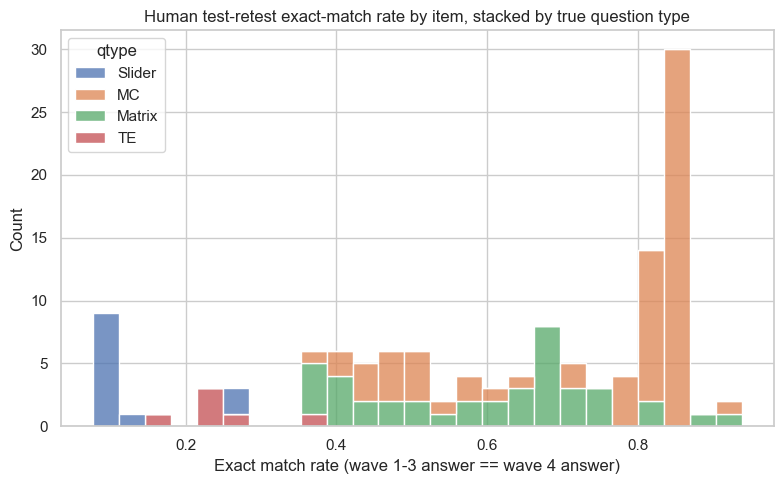

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=reliability_df, x="exact_match_rate", hue="qtype", bins=25, ax=ax, multiple="stack")
ax.set_title("Human test-retest exact-match rate by item, stacked by true question type")
ax.set_xlabel("Exact match rate (wave 1-3 answer == wave 4 answer)")
plt.tight_layout()
plt.show()


**How to read the ceiling.** Report it **per question type**, with the metric that type will be
scored on in eval (Section 3). A model that beats human test-retest on an item almost always
means leakage or overfitting, not a better twin. Wave 4 does **not** re-ask stable traits
(Big Five, demographics), so this ceiling is silent on those constructs. Slider exact-match will
look terrible (~single-digit %) even when Pearson r / ICC is moderate — that is scale granularity,
not "humans are random".


## 6. The leakage trap

Two related traps, both stemming from the same fact: **wave 4 re-asks wave 1–3 questions.**

1. **`full_persona.persona_text` / `persona_json` already contain the wave-4 answer** for any
   repeated question ("For questions that appear in both waves 1-3 and wave 4, the wave 4 responses
   are used" — per the dataset card). Using `full_persona` as the conditioning "persona" for a model
   that then predicts those same wave-4 answers is directly leaking the label into the input.
   **`wave_split.wave1_3_persona_text/json` is the leakage-safe persona** — it's built only from
   waves 1–3.
2. **Even within `wave_split`, `wave4_Q_wave1_3_A` must never be used as a model input** for the
   *same* item it's predicting — it's a diagnostic column for computing the human ceiling (Section 5
   above), not a feature. It's fine to use as a *baseline predictor* ("predict wave 4 = wave 1-3
   answer") but must be clearly separated from anything the model itself conditions on.

We verify trap #1 concretely below: pick a repeated column, show `full_persona`'s embedded answer
already matches the wave-4 ground truth (i.e., proving the leak) versus the true wave1-3 answer.


In [ ]:
# Prove trap #1 from the data, not from the dataset-card sentence.
# Need both HF configs: full_persona (leaky) vs wave_split (safe).
if "full_persona" not in globals() or full_persona is None or len(full_persona) == 0:
    full_persona = load_dataset(REPO_ID, "full_persona")["data"].to_pandas()
    full_persona["pid"] = pd.to_numeric(full_persona["pid"], errors="raise").astype("int64")
if "wave_split" not in globals() or wave_split is None or len(wave_split) == 0:
    wave_split = load_dataset(REPO_ID, "wave_split")["data"].to_pandas()
    wave_split["pid"] = pd.to_numeric(wave_split["pid"], errors="raise").astype("int64")

def iter_questions(obj):
    if isinstance(obj, dict):
        if obj.get("QuestionID") is not None and "Answers" in obj:
            yield obj
        for v in obj.values():
            yield from iter_questions(v)
    elif isinstance(obj, list):
        for v in obj:
            yield from iter_questions(v)

def answers_for_qid(persona_json, qid):
    blob = json.loads(persona_json) if isinstance(persona_json, str) else persona_json
    return [q.get("Answers") for q in iter_questions(blob) if str(q.get("QuestionID")) == str(qid)]

# Prefer a slider/MC where this person's wave-4 answer actually changed.
sample_col = "QID154" if "QID154" in overlap_cols else overlap_cols[0]
diff = merged[
    merged[f"{sample_col}_w13"].notna() & merged[f"{sample_col}_w4"].notna()
    & (merged[f"{sample_col}_w13"] != merged[f"{sample_col}_w4"])
]
if diff.empty:
    diff = merged[merged[f"{sample_col}_w13"].notna() & merged[f"{sample_col}_w4"].notna()]
sample_pid = int(diff["pid"].iloc[0])
qid = question_meta(sample_col)["qid"]
w13_answer = w13_num.loc[w13_num.pid == sample_pid, sample_col].values[0]
w4_answer = w4_num.loc[w4_num.pid == sample_pid, sample_col].values[0]

fp_ans = answers_for_qid(
    full_persona.loc[full_persona.pid == sample_pid, "persona_json"].iloc[0], qid)
ws_ans = answers_for_qid(
    wave_split.loc[wave_split.pid == sample_pid, "wave1_3_persona_json"].iloc[0], qid)

print(f"pid={sample_pid}  column={sample_col}  QuestionID={qid}  type={question_meta(sample_col)['qtype']}")
print(f"  CSV wave 1-3 answer : {w13_answer}")
print(f"  CSV wave 4 answer   : {w4_answer}")
print(f"  full_persona.persona_json Answers     : {fp_ans}")
print(f"  wave_split.wave1_3_persona_json Answers: {ws_ans}")
print("Leak if full_persona embeds the wave-4 CSV value (or a text form of it) rather than wave 1-3.")


In [28]:
leak_risk_share = len(overlap_cols) / len(w13_cols)
print(f"{len(overlap_cols)} / {len(w13_cols)} (~{leak_risk_share:.1%}) of wave1-3 columns "
      f"are re-asked in wave 4 -> every one of these is a potential leak point if the wrong "
      f"persona field is used as model input.")


126 / 760 (~16.6%) of wave1-3 columns are re-asked in wave 4 -> every one of these is a potential leak point if the wrong persona field is used as model input.


## 7. Biases & limitations

- **Panel self-selection.** Participants are drawn from an online survey panel, which systematically
  under-represents people with limited internet access/literacy and over-represents habitual
  survey-takers (professional respondents), a known bias in panel-based "representative" samples.
- **Social desirability bias.** Self-reported behavioral-economics and psychological-scale answers
  are vulnerable to respondents answering how they'd like to be seen rather than how they'd actually
  act — most relevant for sensitive items (risk, honesty, spending).
- **Two-week test-retest window.** The reliability ceiling in Section 5 reflects consistency over
  *two weeks specifically*; it is not evidence of consistency over months/years, and shouldn't be
  extrapolated as a general "how stable are people" constant — real-world deployment gaps are
  usually much longer, so the true ceiling for a production use case is likely **lower** than what
  we measure here.
- **Point-in-time snapshot.** Data collection reflects attitudes/behavior at a single point in time
  (per the dataset card); it will drift as economic conditions, culture, and each individual's own
  circumstances change — relevant to `docs/05_maintenance.md`.
- **Wave 4 is a subset, not attrition.** Both CSVs have the same 2,058 `pid`s. Wave 4 simply re-asks
  fewer items (heuristics/biases + pricing). High item-level missingness on overlap columns is
  mostly **between-subject experimental conditions** (each person saw one arm), not dropout.


In [30]:
# Panel attrition: does every pid in wave1-3 also appear in wave4?
missing_in_w4 = set(w13_num["pid"]) - set(w4_num["pid"])
print(f"Participants in wave1-3 but missing from wave4: {len(missing_in_w4)} "
      f"({len(missing_in_w4) / w13_num['pid'].nunique():.1%})  — expected 0 if this is a balanced panel.")

miss_rows = []
for col in overlap_cols:
    meta = question_meta(col)
    miss_rows.append({
        "column": col,
        "qtype": meta["qtype"],
        "block": meta["block"],
        "missing_rate": float(merged[f"{col}_w4"].isna().mean()),
    })
item_missing_df = pd.DataFrame(miss_rows).sort_values("missing_rate", ascending=False)
item_missing = item_missing_df.set_index("column")["missing_rate"]  # used by the Excel export

print(f"Overlap items with wave4 missing >40%: {(item_missing_df.missing_rate > 0.4).sum()} / {len(item_missing_df)}")
print("Highest-missing items (block names are experimental arms, not 'people dropped out'):")
display_cols = ["column", "block", "missing_rate"]
print(item_missing_df.head(10)[display_cols].to_string(index=False))

# Complementarity check: anchoring high vs low should partition the sample.
def cols_for_block_contains(*needles):
    needles = tuple(n.lower() for n in needles)
    return [c for c in overlap_cols
            if all(n in question_meta(c)["block"].lower() for n in needles)]

high = cols_for_block_contains("anchoring", "african", "high")
low = cols_for_block_contains("anchoring", "african", "low")
if high and low:
    h, l = high[0], low[0]
    both = merged[f"{h}_w4"].notna() & merged[f"{l}_w4"].notna()
    either = merged[f"{h}_w4"].notna() | merged[f"{l}_w4"].notna()
    print(f"\nBetween-subject check: {h} ({question_meta(h)['block']}) vs {l} ({question_meta(l)['block']})")
    print(f"  answered HIGH: {int(merged[f'{h}_w4'].notna().sum())}")
    print(f"  answered LOW : {int(merged[f'{l}_w4'].notna().sum())}")
    print(f"  answered BOTH (should be ~0): {int(both.sum())}")
    print(f"  answered either: {int(either.sum())} / {len(merged)}")


Participants in wave1-3 but missing from wave4: 0 (0.0%)  — expected 0 if this is a balanced panel.
Overlap items with wave4 missing >40%: 56 / 126
Highest-missing items (block names are experimental arms, not 'people dropped out'):
column                                  block  missing_rate
QID179                Proportion dominance 2C      0.683673
QID176                Proportion dominance 1C      0.683673
QID173                  Less is More Gamble C      0.683673
QID172                  Less is More Gamble B      0.673469
QID178                Proportion dominance 2B      0.673469
QID175                Proportion dominance 1B      0.673469
QID190 WTA/WTP Thaler problem - WTA certainty      0.672983
QID191      WTA/WTP Thaler - WTP noncertainty      0.672983
QID189 WTA/WTP Thaler problem - WTP certainty      0.654033
QID171                  Less is More Gamble A      0.642857

Between-subject check: QID165 (Anchoring - African countries high) vs QID163 (Anchoring - African countrie

## 8. Export full tables to Excel

Jupyter/`pandas` truncates wide dataframes (`...` between columns) and long text fields
(`persona_text`, `persona_summary`) in the notebook display above. Everything below writes the
**full, untruncated** data to a single multi-sheet `.xlsx` so you can scroll/search it properly in
Excel — no `pandas` display options change what's actually written here.

Sheets:
- `question_catalog` — full question catalog (QuestionID, QuestionText, QuestionType, options)
- `qtype_scoring` — question-type -> metric mapping (Section 3)
- `reliability` — per-item human test-retest stats (Section 5) — **the key output to review**
- `reliability_summary` — the aggregated ceiling numbers, by question type
- `demographics_sample` — first 500 rows of the demographic columns (Section 4), full sample is large so we cap this sheet
- `item_missingness` — per-item nonresponse in the overlap columns (Section 7)
- `persona_sample` — first 25 people's `persona_text`/`persona_summary`, untruncated, for spot-checking wording

Only in-memory results already computed above are exported — run all prior cells first.


In [ ]:
import os

os.makedirs("../results", exist_ok=True)
EXPORT_PATH = "../results/data_exploration_export.xlsx"

# Full question catalog as a flat table (QuestionID/QuestionType/etc. + options as a joined string)
catalog_rows = []
for q in question_catalog:
    opts = q.get("Options")
    catalog_rows.append({
        "QuestionID": q.get("QuestionID"),
        "QuestionText": q.get("QuestionText"),
        "QuestionType": q.get("QuestionType"),
        "CSV_columns": "; ".join(q.get("csv_columns") or []),
        "Selector": (q.get("Settings") or {}).get("Selector"),
        "is_descriptive": q.get("is_descriptive"),
        "Options": "; ".join(opts) if isinstance(opts, list) else opts,
    })
catalog_export_df = pd.DataFrame(catalog_rows)

# Persona text sample -- untruncated, first 25 people
if "full_persona" in globals() and len(full_persona) and "persona_text" in full_persona.columns:
    persona_cols = [c for c in ["pid", "persona_summary", "persona_text"] if c in full_persona.columns]
    persona_sample_df = full_persona[persona_cols].head(25)
else:
    persona_sample_df = pd.DataFrame(
        {"note": ["full_persona not loaded — run Section 2 / leakage cells first"]}
    )

with pd.ExcelWriter(EXPORT_PATH, engine="openpyxl") as writer:
    catalog_export_df.to_excel(writer, sheet_name="question_catalog", index=False)
    qtype_df.to_excel(writer, sheet_name="qtype_scoring", index=False)
    reliability_df.sort_values("exact_match_rate").to_excel(writer, sheet_name="reliability", index=False)
    (reliability_df.groupby("qtype")[["exact_match_rate", "cohen_kappa", "mean_abs_diff", "pearson_r", "icc_a1"]]
                    .mean().reset_index()
                    .to_excel(writer, sheet_name="reliability_summary", index=False))
    demo_df.head(500).to_excel(writer, sheet_name="demographics_sample", index=False)
    if "representativeness_df" in globals():
        representativeness_df.to_excel(writer, sheet_name="representativeness", index=False)
    item_missing_df.to_excel(writer, sheet_name="item_missingness", index=False)
    persona_sample_df.to_excel(writer, sheet_name="persona_sample", index=False)

print(f"Wrote {EXPORT_PATH}")


In [ ]:
# Auto-fit column widths and freeze the header row so the workbook is actually pleasant to browse.
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

wb = load_workbook(EXPORT_PATH)
for ws in wb.worksheets:
    ws.freeze_panes = "A2"
    for i, col_cells in enumerate(ws.columns, start=1):
        max_len = max((len(str(c.value)) if c.value is not None else 0) for c in col_cells)
        ws.column_dimensions[get_column_letter(i)].width = min(max(max_len + 2, 10), 60)
wb.save(EXPORT_PATH)

print(f"Formatted and saved: {EXPORT_PATH}")
print("Sheets:", wb.sheetnames)


> Re-run this section any time after re-executing earlier cells to refresh `results/data_exploration_export.xlsx`
> — the file is git-ignored by default (add `results/*.xlsx` to `.gitignore` if you don't want to
> commit it); commit a small representative copy instead if you want reviewers to see it without
> running the notebook.


## 9. Summary — what feeds the other deliverables

| Finding | Feeds into |
|---|---|
| `wave_split.wave1_3_persona_*` is the leakage-safe persona; `full_persona` already embeds wave-4 answers for repeated items | `docs/02_model_plan.md` (data pipeline), `docs/03_eval_strategy.md` (leakage prevention) |
| Human test-retest **by question type** with type-appropriate metrics (Section 5). Do not average Slider exact-match with MC accuracy | `docs/03_eval_strategy.md` (ceiling + acceptance criteria) |
| MC includes 21 multi-select items; DB is excluded; map columns via `csv_columns` | `docs/03_eval_strategy.md` (per-type scoring) |
| Sample vs ACS 2023 gaps (Section 4) | `docs/04_business_apps.md` (who this generalizes to) |
| Between-subject missingness ≠ attrition; 2-week ceiling; panel/social-desirability bias | `docs/05_maintenance.md` |

Next: `docs/02_model_plan.md` for the modeling approach.
